# Feature and hyperparameter search

Notebook 2 found numeric gradient boosting to be the strongest model family, while contextual logistic regression remained easier to explain and export into a static browser application. This notebook carries both forward on identical chronological folds. It searches logistic features and regularization, retains the Notebook 2 boosted model as a performance control, and separately tests the granularity of course identity.


## 1. Load Notebook 1's canonical cache

Notebook 1 owns archive parsing, label construction, feature engineering, and deterministic sampling. This notebook reads the resulting per-session cache and performs no reconstruction.


In [1]:
from __future__ import annotations

import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()), cwd)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 5
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ['20239', '20249', '20259', '20265']
TRAIN_ROWS_PER_FOLD = 2_000_000
paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in SESSION_ORDER}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
for frame in session_samples.values():
    parts = frame['course_code'].str.extract(r'^([A-Z]+)(\d)(\d{2})')
    frame['department'] = parts[0].fillna('UNKNOWN')
    frame['course_level'] = parts[1].fillna('UNKNOWN')
    frame['department_level'] = frame['department'] + frame['course_level']
    frame['course_number'] = (parts[0] + parts[1] + parts[2]).fillna('UNKNOWN')
print(f'Loaded {sum(map(len, session_samples.values())):,} cached modelling rows')


Loaded 2,383,644 cached modelling rows


## 2. Candidate feature sets and models

The main search compares raw and normalized logistic feature sets, regularization strengths, lecture identity, and the numeric gradient-boosting leader from Notebook 2. Every candidate uses identical cached training and validation rows within each chronological fold.

A second controlled search below isolates how course identity should be represented inside the logistic candidate.


In [2]:
RAW_NUMERIC = [
    'position', 'waitlist', 'capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'capacity_changed_7d',
]
RATIO_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'position_to_waitlist',
    'days_to_deadline', 'movement_velocity_7d', 'capacity_changed_7d',
]
ALL_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
CONTEXT_CATEGORICAL = ['course_code', 'campus', 'term']
RANK_MONOTONIC = {'position_to_capacity': -1, 'position': -1, 'position_to_waitlist': -1}
LECTURE_CATEGORICAL = CONTEXT_CATEGORICAL + ['meeting', 'lecture_number']

def logistic_pipeline(numeric, categorical, C=1.0):
    features = ColumnTransformer([
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value=0)),
            ('scale', StandardScaler()),
        ]), numeric),
        ('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=3), categorical),
    ])
    return Pipeline([
        ('features', features),
        ('model', LogisticRegression(C=C, solver='lbfgs', max_iter=300)),
    ])

def boosted_pipeline():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), ALL_NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
            monotonic_cst=[RANK_MONOTONIC.get(feature, 0) for feature in ALL_NUMERIC],
        )),
    ])


CANDIDATES = {
    'boosted_numeric': boosted_pipeline,
    'raw_C0.3': lambda: logistic_pipeline(RAW_NUMERIC, CONTEXT_CATEGORICAL, C=0.3),
    'ratio_C0.3': lambda: logistic_pipeline(RATIO_NUMERIC, CONTEXT_CATEGORICAL, C=0.3),
    'context_C0.03': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=0.03),
    'context_C0.1': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=0.1),
    'context_C0.3': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=0.3),
    'context_C1': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=1.0),
    'context_C3': lambda: logistic_pipeline(ALL_NUMERIC, CONTEXT_CATEGORICAL, C=3.0),
    'lecture_C0.1': lambda: logistic_pipeline(ALL_NUMERIC, LECTURE_CATEGORICAL, C=0.1),
    'lecture_C0.3': lambda: logistic_pipeline(ALL_NUMERIC, LECTURE_CATEGORICAL, C=0.3),
    'lecture_C1': lambda: logistic_pipeline(ALL_NUMERIC, LECTURE_CATEGORICAL, C=1.0),
}
print(f'{len(CANDIDATES)} targeted candidates')

11 targeted candidates


## 3. Chronological search

Every candidate sees identical cached rows in each fold. Results are checkpointed after every fit, so an interrupted kernel can resume without losing completed work.

In [3]:
RESULTS_PATH = CACHE_ROOT / 'feature-search-canonical-v2.pkl'
results = pd.read_pickle(RESULTS_PATH).to_dict('records') if RESULTS_PATH.exists() else []
completed = {(row['validation_session'], row['candidate']) for row in results}

def weighted_ece(y, probability, weight, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    groups = np.clip(np.digitize(probability, edges) - 1, 0, bins - 1)
    total = weight.sum()
    error = 0.0
    for group_number in range(bins):
        mask = groups == group_number
        if mask.any():
            observed = np.average(y[mask], weights=weight[mask])
            predicted = np.average(probability[mask], weights=weight[mask])
            error += weight[mask].sum() / total * abs(observed - predicted)
    return float(error)

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train_sessions = SESSION_ORDER[:valid_index]
    train = pd.concat([session_samples[s] for s in train_sessions], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=42)
    valid = session_samples[valid_session]
    print(f'Fold {valid_session}: {len(model_train):,} training rows; {len(valid):,} validation rows', flush=True)

    for candidate_number, (name, factory) in enumerate(CANDIDATES.items(), start=1):
        key = (valid_session, name)
        if key in completed:
            print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {valid_session} {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {valid_session} {name}: fitting', flush=True)
        numeric = RAW_NUMERIC if name.startswith('raw_') else RATIO_NUMERIC if name.startswith('ratio_') else ALL_NUMERIC
        categorical = (
            [] if name == 'boosted_numeric'
            else LECTURE_CATEGORICAL if name.startswith('lecture_')
            else CONTEXT_CATEGORICAL
        )
        feature_columns = numeric + categorical
        model = factory()
        model.fit(model_train[feature_columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = np.clip(model.predict_proba(valid[feature_columns])[:, 1], 1e-6, 1 - 1e-6)
        y = valid['cleared'].to_numpy()
        w = valid['model_weight'].to_numpy()
        results.append({
            'validation_session': valid_session,
            'candidate': name,
            'brier': brier_score_loss(y, probability, sample_weight=w),
            'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
            'ece_10': weighted_ece(y, probability, w),
            'roc_auc': roc_auc_score(y, probability, sample_weight=w),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(results).to_pickle(RESULTS_PATH)
        completed.add(key)
        print(f'  complete in {results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

scores = pd.DataFrame(results).sort_values(['validation_session', 'brier']).reset_index(drop=True)
display(scores)

Fold 20239: 583,644 training rows; 300,000 validation rows


[1/4, 1/11] 20239 boosted_numeric: fitting


  complete in 0.0 min


[1/4, 2/11] 20239 raw_C0.3: fitting


  complete in 0.0 min


...

[4/4, 10/11] 20265 lecture_C0.3: fitting


  complete in 0.2 min


[4/4, 11/11] 20265 lecture_C1: fitting


  complete in 0.3 min


,validation_session,candidate,brier,log_loss,ece_10,roc_auc,seconds
0,20239,boosted_numeric,0.050922,0.167333,0.018144,0.952256,2.706400
1,20239,context_C3,0.056204,0.194547,0.017762,0.932789,3.393190
2,20239,context_C1,0.057193,0.195884,0.017698,0.930945,2.800719
3,20239,lecture_C1,0.057251,0.195803,0.018021,0.931028,3.714117
4,20239,lecture_C0.3,0.059588,0.203663,0.018786,0.924625,3.367278
5,20239,context_C0.3,0.059617,0.203924,0.018653,0.924459,2.466784
6,20239,lecture_C0.1,0.062818,0.212255,0.020418,0.917092,3.158260
7,20239,context_C0.1,0.062882,0.212567,0.020472,0.916956,2.275385
8,20239,raw_C0.3,0.065391,0.235445,0.028355,0.901349,2.031325
9,20239,ratio_C0.3,0.065425,0.234130,0.022752,0.903673,1.780417


## 4. Select a stable winner

Prefer the lowest mean Brier score, but reject a candidate that wins only one fold or materially worsens calibration. The main holdout remains `20259`.

,mean_brier,worst_brier,mean_log_loss,mean_ece,mean_auc,total_minutes
candidate,,,,,,
boosted_numeric,0.051058,0.055246,0.172376,0.017339,0.944133,0.387421
context_C3,0.057208,0.060168,0.191405,0.016516,0.933090,0.615569
context_C1,0.057497,0.059698,0.191607,0.016276,0.932959,0.509502
lecture_C1,0.057546,0.059739,0.191822,0.015829,0.932532,0.677546
lecture_C0.3,0.058823,0.060211,0.195423,0.018260,0.930616,0.542770
context_C0.3,0.058836,0.060286,0.195472,0.019403,0.930808,0.416033
lecture_C0.1,0.061081,0.063125,0.202104,0.022971,0.926925,0.490880
context_C0.1,0.061146,0.063350,0.202354,0.023239,0.926819,0.357522
context_C0.03,0.065038,0.068240,0.214244,0.029769,0.919055,0.324199


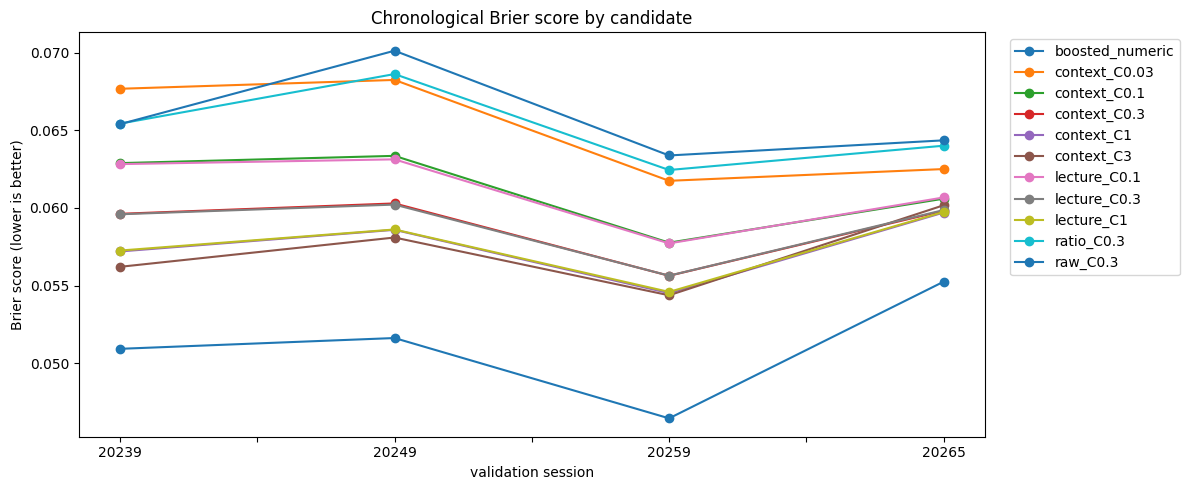

Provisional winner: boosted_numeric


In [4]:
summary = scores.groupby('candidate').agg(
    mean_brier=('brier', 'mean'),
    worst_brier=('brier', 'max'),
    mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
    total_minutes=('seconds', lambda values: values.sum() / 60),
).sort_values(['mean_brier', 'mean_ece'])
display(summary)

pivot = scores.pivot(index='validation_session', columns='candidate', values='brier')
ax = pivot.plot(figsize=(12, 5), marker='o')
ax.set(title='Chronological Brier score by candidate', ylabel='Brier score (lower is better)', xlabel='validation session')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

winner = summary.index[0]
print('Provisional winner:', winner)

## 5. Course-identity granularity experiment

The existing model uses the complete code such as `CSC369H1F`. This controlled experiment keeps the numeric features, campus, term, regularization (`C=3`), folds, and cached rows fixed while changing only the representation of course identity:

- no course identity
- department only (`CSC`)
- year level only (`3`)
- department and level as separate features (`CSC` + `3`)
- department-level as one feature (`CSC3`)
- course number without campus or term (`CSC369`)
- the current complete code (`CSC369H1F`)


In [5]:
GRANULARITY = {
    'no_course': ['campus', 'term'],
    'department_only': ['department', 'campus', 'term'],
    'level_only': ['course_level', 'campus', 'term'],
    'department_plus_level': ['department', 'course_level', 'campus', 'term'],
    'department_level': ['department_level', 'campus', 'term'],
    'course_number': ['course_number', 'campus', 'term'],
    'full_course_code': ['course_code', 'campus', 'term'],
}
GRANULARITY_PATH = CACHE_ROOT / 'course-granularity-canonical-v2.pkl'
granularity_results = pd.read_pickle(GRANULARITY_PATH).to_dict('records') if GRANULARITY_PATH.exists() else []
granularity_completed = {(row['validation_session'], row['representation']) for row in granularity_results}

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train = pd.concat([session_samples[s] for s in SESSION_ORDER[:valid_index]], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=42)
    valid = session_samples[valid_session]
    for variant_number, (name, categorical) in enumerate(GRANULARITY.items(), start=1):
        key = (valid_session, name)
        if key in granularity_completed:
            print(f'[{fold_number}/4, {variant_number}/{len(GRANULARITY)}] {valid_session} {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {variant_number}/{len(GRANULARITY)}] {valid_session} {name}: fitting', flush=True)
        columns = ALL_NUMERIC + categorical
        model = logistic_pipeline(ALL_NUMERIC, categorical, C=3.0)
        model.fit(model_train[columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = np.clip(model.predict_proba(valid[columns])[:, 1], 1e-6, 1 - 1e-6)
        y = valid['cleared'].to_numpy()
        w = valid['model_weight'].to_numpy()
        granularity_results.append({
            'validation_session': valid_session,
            'representation': name,
            'brier': brier_score_loss(y, probability, sample_weight=w),
            'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
            'ece_10': weighted_ece(y, probability, w),
            'roc_auc': roc_auc_score(y, probability, sample_weight=w),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(granularity_results).to_pickle(GRANULARITY_PATH)
        granularity_completed.add(key)
        print(f'  complete in {granularity_results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

granularity_scores = pd.DataFrame(granularity_results)
granularity_summary = granularity_scores.groupby('representation').agg(
    mean_brier=('brier','mean'), worst_brier=('brier','max'),
    mean_log_loss=('log_loss','mean'), mean_ece=('ece_10','mean'),
    mean_auc=('roc_auc','mean'), total_minutes=('seconds', lambda x: x.sum()/60),
).sort_values(['mean_brier','mean_ece'])
display(granularity_summary)
display(granularity_scores.pivot(index='validation_session', columns='representation', values='brier'))


[1/4, 1/7] 20239 no_course: fitting


  complete in 0.0 min


[1/4, 2/7] 20239 department_only: fitting


  complete in 0.1 min


[1/4, 3/7] 20239 level_only: fitting


...

  complete in 0.2 min


[4/4, 7/7] 20265 full_course_code: fitting


  complete in 0.2 min


,mean_brier,worst_brier,mean_log_loss,mean_ece,mean_auc,total_minutes
representation,,,,,,
course_number,0.056866,0.059581,0.191010,0.015976,0.932602,0.625428
department_plus_level,0.057174,0.059112,0.191310,0.015830,0.932891,0.601546
full_course_code,0.057208,0.060168,0.191405,0.016516,0.933090,0.615979
department_only,0.057290,0.059446,0.191918,0.015944,0.932412,0.512583
department_level,0.057355,0.059819,0.192260,0.016212,0.931824,0.547958
level_only,0.057690,0.059435,0.193164,0.015636,0.932073,0.392237
no_course,0.058065,0.060034,0.194986,0.016133,0.930653,0.257785


representation,course_number,department_level,department_only,department_plus_level,full_course_code,level_only,no_course
validation_session,,,,,,,
20239,0.055427,0.055883,0.055925,0.055708,0.056204,0.056921,0.057698
20249,0.057780,0.059185,0.059446,0.059112,0.058090,0.059435,0.060034
20259,0.054677,0.054531,0.054868,0.054910,0.054370,0.055218,0.055420
20265,0.059581,0.059819,0.058920,0.058967,0.060168,0.059184,0.059110


## 6. Findings and decision

All candidates were trained on the same deterministic rows and evaluated on the same four chronological holdouts.

### Model and feature search

- `boosted_numeric` won **all four validation sessions** with **0.05106 mean Brier**, **0.01734 mean ECE**, and **0.94413 mean ROC AUC**.
- `context_C3` was the best logistic candidate with **0.05721 mean Brier**, **0.01652 mean ECE**, and **0.93309 mean ROC AUC**.
- Boosting reduced mean Brier error by **10.7%** relative to the best logistic candidate and had better discrimination, while `context_C3` had marginally lower mean ECE.
- Adding lecture identity did not help. The best lecture-aware candidate had **0.05755 mean Brier**, worse than `context_C3`.
- Weaker regularization consistently helped logistic regression. Among the tested values, `C=3` was best.

### Course-identity experiment

- Course number produced the lowest mean Brier at **0.05687**, ahead of full course code at **0.05721** and no course identity at **0.05807**.
- Level-only features had the best mean ECE at **0.01564**; separate department and level features reached **0.05717 mean Brier**.
- Combining department and level into a single value did not improve on keeping them separate.
- Course identity adds modest signal, but no representation approached the boosted model.

### Decision

`boosted_numeric` remains the primary model family. The performance gap is too large to select logistic regression solely for simpler browser export. Notebook 4 must evaluate calibration and failure slices for boosting while retaining `context_C3` as the interpretable comparison model. Browser export for the tree ensemble is an implementation task, not a reason to discard the statistical winner.
